# 01 · Data quality: from raw to clean prices

This notebook documents **Step 2** of the project. It inspects the raw Yahoo Finance data stored in PostgreSQL (`prices_raw`), explains every issue found, and checks the result of the cleaning pipeline [`src/data/clean_prices.py`](../src/data/clean_prices.py) (`prices_clean` + `cleaning_log`).

**Run first** (from the project root):
```bash
python -m src.data.setup_db
python -m src.data.fetch_prices
python -m src.data.clean_prices
```

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from src.db import PROJECT_ROOT, get_engine

engine = get_engine()
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Chart style: light surface, recessive axes, one accent colour
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#a3a29c", "#e6e5e0", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110, "axes.axisbelow": True,
})
pd.set_option("display.width", 160)

## 1. Load the data from PostgreSQL

In [2]:
raw = pd.read_sql(
    """SELECT p.*, u.name, u.asset_type, u.exchange
       FROM prices_raw p JOIN universe u USING (ticker)""",
    engine, parse_dates=["date"],
).sort_values(["ticker", "date"], ignore_index=True)

clean = pd.read_sql("SELECT * FROM prices_clean", engine, parse_dates=["date"]).sort_values(["ticker", "date"], ignore_index=True)
log = pd.read_sql("SELECT ticker, date, rule, action, detail FROM cleaning_log", engine, parse_dates=["date"])

print(f"Raw rows:   {len(raw):>9,}  ({raw['ticker'].nunique()} tickers)")
print(f"Clean rows: {len(clean):>9,}  ({len(raw) - len(clean):,} dropped, {(len(raw) - len(clean)) / len(raw):.1%})")
print(f"Log rows:   {len(log):>9,}")

Raw rows:     400,133  (60 tickers)
Clean rows:   395,548  (4,585 dropped, 1.1%)
Log rows:      10,957


## 2. What the cleaning did

Each rule was designed from an issue actually observed in the data. The SQL view `cleaning_summary` aggregates the cleaning log:

In [3]:
summary = pd.read_sql("SELECT * FROM cleaning_summary", engine)
summary

,rule,action,n_rows,n_tickers,first_date,last_date
0,stale_bar,dropped,3045,56,2000-01-05,2026-07-21
1,invalid_adj_close,set_null,2355,2,2000-12-01,2008-11-24
2,unreliable_range,set_null,1894,1,2000-01-03,2007-06-29
3,close_only_bar,set_null,1603,37,2000-01-03,2017-07-14
4,before_valid_from,dropped,1447,1,2000-01-03,2005-07-19
5,range_repair,repaired,430,42,2000-01-04,2024-05-14
6,implausible_range,set_null,90,18,2000-10-02,2026-07-22
7,incomplete_session,dropped,60,60,2026-10-01,2026-10-01
8,price_spike,dropped,33,1,2001-04-04,2010-05-14


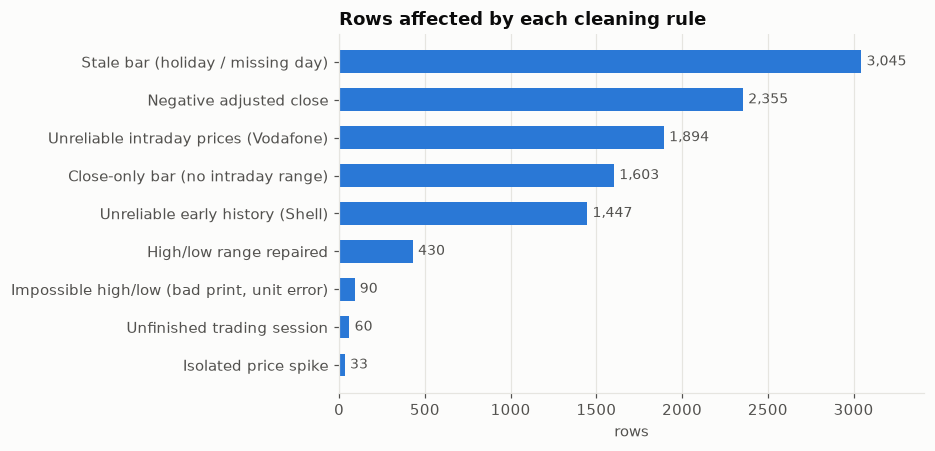

In [4]:
RULE_LABELS = {
    "stale_bar": "Stale bar (holiday / missing day)",
    "invalid_adj_close": "Negative adjusted close",
    "close_only_bar": "Close-only bar (no intraday range)",
    "before_valid_from": "Unreliable early history (Shell)",
    "range_repair": "High/low range repaired",
    "unreliable_range": "Unreliable intraday prices (Vodafone)",
    "implausible_range": "Impossible high/low (bad print, unit error)",
    "incomplete_session": "Unfinished trading session",
    "price_spike": "Isolated price spike",
}
s = summary.groupby("rule")["n_rows"].sum().sort_values()
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.barh([RULE_LABELS.get(r, r) for r in s.index], s.values, color=BLUE, height=0.6)
for y, v in enumerate(s.values):
    ax.text(v + s.max() * 0.01, y, f"{v:,}", va="center", color=INK_2, fontsize=9)
ax.set_title("Rows affected by each cleaning rule")
ax.set_xlabel("rows")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, s.max() * 1.12)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_cleaning_rules.png", dpi=150)
plt.show()

## 3. Stale bars: holidays and missing days filled with an old price

Yahoo sometimes returns a row on days when the exchange was closed (Christmas, 1 May, Good Friday…) or when it has no data. These rows have **zero volume** and simply **repeat the previous close**, so they would add fake zero returns and bias volatility downwards.

A few of them are worse: the open/high/low are flat while the close comes from another day and a different price adjustment (e.g. TotalEnergies on Good Friday 2002: close 43.78 vs open/high/low 10.94).

Note that an unchanged close **with** volume is a genuine trading day and is kept.

In [5]:
stale = log[log["rule"] == "stale_bar"]
print("Most frequent calendar days among stale bars:")
print(stale["date"].dt.strftime("%d %b").value_counts().head(8).to_string())
stale[stale["detail"].str.contains("inconsistent")]

Most frequent calendar days among stale bars:
date
26 Dec    241
25 Dec    205
01 Jan    181
01 May    171
31 Dec    147
24 Dec    135
21 Apr     87
28 Mar     63


,ticker,date,rule,action,detail
8595,TTE.PA,2002-03-29,stale_bar,dropped,"volume 0, close 43.78 inconsistent with flat o..."
10824,VOLV-B.ST,2005-06-06,stale_bar,dropped,"volume 0, close 60.2 inconsistent with flat op..."


## 4. Shell: an unusable early history

Before the unification of Royal Dutch Shell plc in **July 2005**, Yahoo's `SHEL.L` series is mostly frozen: on more than 90% of days in 2000 the price did not move and no volume was reported. Volatility estimated on this period would be meaningless, so `data/universe.csv` sets `valid_from = 2005-07-20` for Shell and earlier rows are dropped.

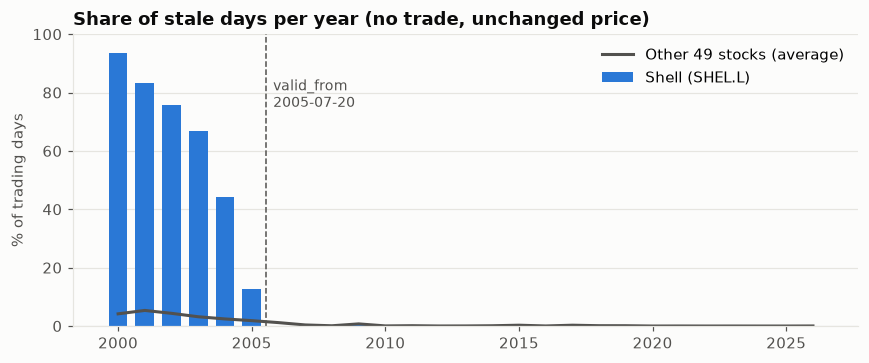

In [6]:
r = raw.copy()
r["stale"] = (r["close"] == r.groupby("ticker")["close"].shift()) & (r["volume"] == 0)
r["year"] = r["date"].dt.year
stocks = r[r["asset_type"] == "stock"]
shell = stocks[stocks["ticker"] == "SHEL.L"].groupby("year")["stale"].mean()
others = stocks[stocks["ticker"] != "SHEL.L"].groupby("year")["stale"].mean()

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(shell.index, shell.values * 100, color=BLUE, width=0.7, label="Shell (SHEL.L)")
ax.plot(others.index, others.values * 100, color=INK_2, lw=2, label="Other 49 stocks (average)")
ax.axvline(2005.55, color=INK_2, lw=1, ls="--")
ax.text(2005.8, 85, "valid_from\n2005-07-20", color=INK_2, fontsize=9, va="top")
ax.set_title("Share of stale days per year (no trade, unchanged price)")
ax.set_ylabel("% of trading days")
ax.set_ylim(0, 100)
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_shell_stale_history.png", dpi=150)
plt.show()

## 5. Price spikes: Novo Nordisk

Novo Nordisk shows 47 daily moves above 50% in the raw data. They are **isolated bad prints**: a price 2× or 5× away from its neighbours, always with zero volume, that reverts the next day (apparently prices that were not adjusted for later stock splits).

The `price_spike` rule drops a close that is more than 40% away from **both** the median of the 5 previous and the 5 next closes. A genuine crash is not affected because the price stays at its new level, e.g. ABB lost 62% on 22 Oct 2002 (asbestos liabilities) and that day is kept.

The chart shows why this matters for the project: each bad print creates a huge fake return, which inflates estimated volatility.

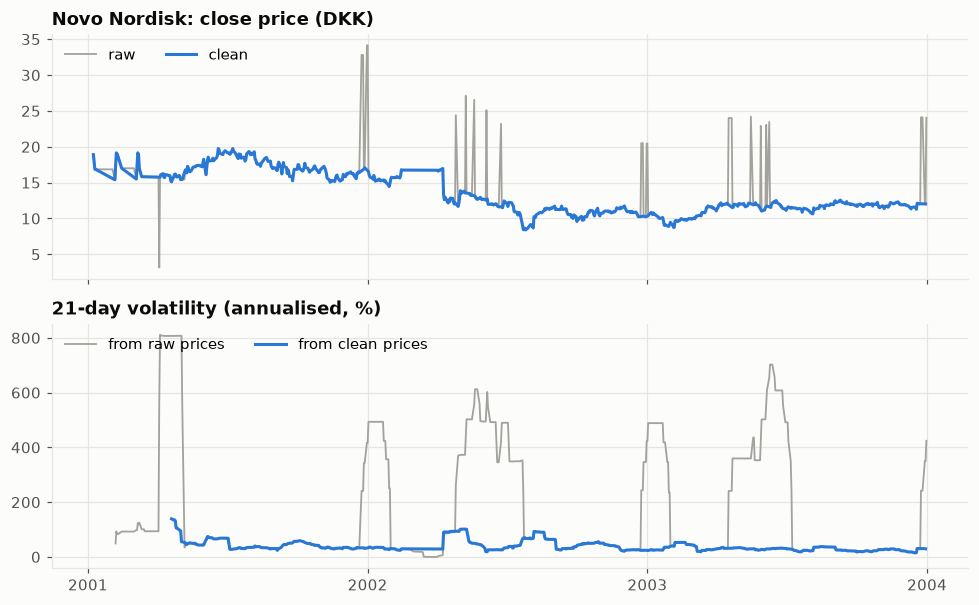

Mean 21-day volatility 2001-2003: raw 160% vs clean 40%


In [7]:
start, end = "2001-01-01", "2003-12-31"
nr = raw[(raw["ticker"] == "NOVO-B.CO") & raw["date"].between(start, end)].set_index("date")["close"]
nc = clean[(clean["ticker"] == "NOVO-B.CO") & clean["date"].between(start, end)].set_index("date")["close"]

def rolling_vol(close, window=21):
    """Annualised rolling volatility of daily log returns, in %."""
    return np.log(close).diff().rolling(window).std() * np.sqrt(252) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.6), sharex=True)
ax1.plot(nr.index, nr.values, color=MUTED, lw=1.2, label="raw")
ax1.plot(nc.index, nc.values, color=BLUE, lw=2, label="clean")
ax1.set_title("Novo Nordisk: close price (DKK)")
ax1.legend(loc="upper left", ncols=2)

ax2.plot(nr.index, rolling_vol(nr), color=MUTED, lw=1.2, label="from raw prices")
ax2.plot(nc.index, rolling_vol(nc), color=BLUE, lw=2, label="from clean prices")
ax2.set_title("21-day volatility (annualised, %)")
ax2.legend(loc="upper left", ncols=2)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
fig.savefig(FIG_DIR / "02_novo_spikes.png", dpi=150)
plt.show()

print(f"Mean 21-day volatility {start[:4]}-{end[:4]}: raw {rolling_vol(nr).mean():.0f}% vs clean {rolling_vol(nc).mean():.0f}%")

In [8]:
# Spikes removed, with the neighbouring prices that triggered the rule
log[log["rule"] == "price_spike"].head(10)

,ticker,date,rule,action,detail
6096,NOVO-B.CO,2001-04-04,price_spike,dropped,"close 3.165 vs neighbours 15.82 / 15.75, volume 0"
6101,NOVO-B.CO,2001-12-24,price_spike,dropped,"close 32.8 vs neighbours 16.4 / 16.88, volume 0"
6104,NOVO-B.CO,2001-12-31,price_spike,dropped,"close 34.15 vs neighbours 17.08 / 16.55, volume 0"
6137,NOVO-B.CO,2002-04-26,price_spike,dropped,"close 24.4 vs neighbours 12.2 / 11.68, volume 0"
6138,NOVO-B.CO,2002-05-09,price_spike,dropped,"close 27.1 vs neighbours 13.55 / 13.55, volume 0"
6139,NOVO-B.CO,2002-05-20,price_spike,dropped,"close 26.55 vs neighbours 13.27 / 13.12, volume 0"
6140,NOVO-B.CO,2002-06-05,price_spike,dropped,"close 25.1 vs neighbours 12.55 / 12.73, volume 0"
6141,NOVO-B.CO,2002-06-24,price_spike,dropped,"close 23.2 vs neighbours 11.62 / 11.62, volume 0"
6142,NOVO-B.CO,2002-12-24,price_spike,dropped,"close 20.5 vs neighbours 10.25 / 10.32, volume 0"
6145,NOVO-B.CO,2002-12-31,price_spike,dropped,"close 20.45 vs neighbours 10.23 / 10.38, volume 0"


## 6. Intraday prices: inconsistent, impossible and close-only bars

Open, high and low matter for this project because the best daily volatility estimators are built from the intraday range (Step 4). Four situations are handled; in the last three the **close is kept** and only open/high/low are set to NULL, so range-based estimators fall back to close-to-close returns.

* **Unreliable range (Vodafone):** before mid-2007 Yahoo's open and high for `VOD.L` are frequently on a different price basis than the close (the open is often about 14% above it, apparently an artefact of the July 2006 share consolidation), which makes range-based volatility 10 to 100 times too high. `data/universe.csv` sets `range_valid_from = 2007-07-01`.
* **Implausible range:** a high more than twice the low (a low quoted in pounds instead of pence on Shell and BP in 2019), or a high / low more than 15% beyond **both** the open and the close (a bad print: the price would have had to leave and come back within the day). A genuine intraday crash closes near its low and is not affected. Not applied to the VIX.
* **Range repair:** on some days, mostly before 2005, the close (or open) lies outside the reported [low, high] range. The close is the most reliable field, so the range is widened to include it.
* **Close-only bars:** early in the sample some series (FTSE MIB until 2003, Vodafone until 2002, Nestlé…) only report a closing price, with open = high = low = close. These bars carry no intraday information: open/high/low are set to NULL so that **range-based volatility estimators (Parkinson, Garman-Klass) will not treat them as zero-range days** in Step 4.

In [9]:
# Examples of impossible bars
print(log[log["rule"] == "implausible_range"].sort_values("date").iloc[[0, 40, 60, -1]].to_string(index=False))

by_year = (log[log["rule"].isin(["range_repair", "close_only_bar", "implausible_range", "unreliable_range"])]
           .assign(year=lambda d: d["date"].dt.year)
           .pivot_table(index="year", columns="rule", values="ticker", aggfunc="size", fill_value=0))
by_year.T

ticker       date              rule   action                                         detail
MBG.DE 2000-10-02 implausible_range set_null open 41.98, high 48.78, low 41.89, close 42.34
HSBA.L 2017-02-23 implausible_range set_null     open 662, high 679.7, low 520, close 652.8
SHEL.L 2021-09-29 implausible_range set_null     open 1619, high 1654, low 1283, close 1651
 RIO.L 2026-07-22 implausible_range set_null     open 6764, high 7788, low 5758, close 6903


year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
rule,,,,,,,,,,,,,,,,,,,,,
close_only_bar,594,410,286,160,4,7,15,10,6,86,...,3,0,0,0,0,0,0,0,0,0
implausible_range,2,1,5,2,2,2,0,7,6,7,...,2,0,5,5,10,0,2,3,1,22
range_repair,61,37,29,21,38,86,98,7,8,4,...,6,2,0,0,1,2,2,10,0,0
unreliable_range,253,253,252,253,254,252,252,125,0,0,...,0,0,0,0,0,0,0,0,0,0


## 7. Negative adjusted close prices

Yahoo's `adj_close` is **negative** for AB InBev (2000-2008) and Inditex (2001-2002): the dividend adjustment goes wrong around large capital operations (InBev's 2008 rights issue). Several other adjustment factors jump by 25-40% in a single day; some are genuine special dividends (Maersk 2023), others are not.

Decision for the rest of the project: **returns are computed from `close`**, which Yahoo already adjusts for stock splits, and `adj_close` is kept only for reference (set to NULL where negative). Ignoring dividends adds one small ex-dividend drop per payment, which is negligible for volatility compared with the errors in `adj_close`.

In [10]:
log[log["rule"] == "invalid_adj_close"].groupby("ticker")["date"].agg(["count", "min", "max"])

,count,min,max
ticker,,,
ABI.BR,2023,2000-12-01,2008-11-24
ITX.MC,332,2001-05-24,2002-09-24


## 8. Checks after cleaning

**1. Database constraints.** `prices_clean` enforces `close > 0`, `high >= low`, `open` and `close` within `[low, high]`, and all-or-nothing open/high/low. The insert would have failed otherwise; the query below double-checks.

In [11]:
violations = pd.read_sql("""
    SELECT count(*) FILTER (WHERE close <= 0)                                 AS non_positive_close,
           count(*) FILTER (WHERE high < low)                                 AS high_below_low,
           count(*) FILTER (WHERE close NOT BETWEEN low AND high)             AS close_outside_range,
           count(*) FILTER (WHERE open  NOT BETWEEN low AND high)             AS open_outside_range,
           count(*) FILTER (WHERE adj_close <= 0)                             AS non_positive_adj_close
    FROM prices_clean
""", engine)
violations

,non_positive_close,high_below_low,close_outside_range,open_outside_range,non_positive_adj_close
0,0,0,0,0,0


**2. Largest remaining daily moves.** Every stock move above 30% should correspond to a real event.

In [12]:
c = clean.merge(raw[["ticker", "name", "asset_type"]].drop_duplicates(), on="ticker")
c["return"] = c.groupby("ticker")["close"].pct_change()
big = c[(c["asset_type"] == "stock") & (c["return"].abs() > 0.30)]
big[["ticker", "name", "date", "close", "return"]].sort_values("return")

,ticker,name,date,close,return
709,ABBN.SW,ABB,2002-10-22,1.560175,-0.618250
240843,RIO.L,Rio Tinto,2008-11-25,1280.462646,-0.367347
307270,UBSG.SW,UBS Group,2008-09-19,21.000000,0.316614
208567,NOKIA.HE,Nokia,2013-09-03,3.970000,0.339406
65713,BAYN.DE,Bayer,2003-03-18,14.072559,0.391051
718,ABBN.SW,ABB,2002-11-04,1.864600,0.458334


All of them are genuine market events: ABB's asbestos crisis (Oct 2002) and rebound, Bayer's first favourable Lipobay/Baycol verdict (Mar 2003), the rally after the US bank-rescue plan (UBS, Sep 2008), BHP dropping its bid for Rio Tinto (Nov 2008) and the sale of Nokia's phone business to Microsoft (Sep 2013). They are kept: extreme but real moves are exactly what a volatility model must learn from.

**3. Coverage per ticker** (view `data_coverage`): rows kept, rows dropped and rows with a full intraday range.

In [13]:
coverage = pd.read_sql("SELECT * FROM data_coverage", engine)
coverage.head(12)

,ticker,name,asset_type,country,n_raw,n_clean,n_dropped,n_with_range,first_date,last_date
0,SHEL.L,Shell,stock,United Kingdom,6808,5357,1451,5346,2005-07-20,2026-09-30
1,NDA-FI.HE,Nordea,stock,Finland,6773,6629,144,6629,2000-01-25,2026-09-30
2,NOVO-B.CO,Novo Nordisk,stock,Denmark,6481,6346,135,6303,2001-01-08,2026-09-30
3,MAERSK-B.CO,A.P. Moller-Maersk,stock,Denmark,6755,6636,119,6586,2000-01-03,2026-09-30
4,BAYN.DE,Bayer,stock,Germany,6836,6721,115,6720,2000-01-03,2026-09-30
5,EQNR.OL,Equinor,stock,Norway,6782,6669,113,6668,2000-01-03,2026-09-30
6,ABBN.SW,ABB,stock,Switzerland,6789,6677,112,6672,2000-01-03,2026-09-30
7,VOLV-B.ST,Volvo,stock,Sweden,6787,6691,96,6690,2000-01-03,2026-09-30
8,ERIC-B.ST,Ericsson,stock,Sweden,6787,6692,95,6685,2000-01-03,2026-09-30
9,NOKIA.HE,Nokia,stock,Finland,6789,6699,90,6699,2000-01-03,2026-09-30


## 9. Summary

| Issue | Rule | Decision |
|---|---|---|
| Holidays / missing days filled with an old price | `stale_bar` | Dropped |
| Shell's frozen history before 2005 | `before_valid_from` | Dropped (configurable in `universe.csv`) |
| Isolated bad prints (Novo Nordisk) | `price_spike` | Dropped; genuine crashes kept |
| Intraday prices on a different basis than the close (Vodafone) | `unreliable_range` | Open/high/low set to NULL |
| Impossible high/low (bad prints, pence/pound errors) | `implausible_range` | Open/high/low set to NULL |
| Close outside the high/low range | `range_repair` | Range widened |
| Close-only bars | `close_only_bar` | Open/high/low set to NULL |
| Negative adjusted close | `invalid_adj_close` | Set to NULL; returns use `close` |
| Session still trading at download time | `incomplete_session` | Dropped |

**Checked and not found:** pence/pound unit switches in the *closing* prices of London stocks (largest daily move in clean data below 40%), weekend rows, duplicate dates, missing prices.

**Carried over to Step 4:** the VIX closes after European markets, so it must be lagged by one day when used as a feature.